In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [2]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [3]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [4]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [5]:
rain_file_origin_path = 'data/Rainfall.csv'
rain_origin_data = pd.read_csv(rain_file_origin_path)
rain_file_path = 'data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [6]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [7]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [8]:
score_dataset(X, y)

0.8776175077070999


In [9]:
rain_origin_data

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [10]:
y_origin = rain_origin_data["rainfall"]

In [11]:
X_origin = rain_origin_data.drop(labels="rainfall", axis=1)

In [12]:
X_origin = X_origin.drop(labels="day", axis=1)
X_test = X_test.drop(labels="day", axis=1)

In [13]:
X = X.drop(labels="id", axis=1)
X_test = X_test.drop(labels="id", axis=1)

In [14]:
X = X.drop(labels="day", axis=1)

In [15]:
X_origin.rename(columns={'pressure ': 'pressure', 'humidity ': 'humidity', '         winddirection': 'winddirection', 'cloud ':'cloud' }, inplace=True)

In [16]:
pd.concat([X, X_origin])

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8
...,...,...,...,...,...,...,...,...,...,...
361,1022.7,18.8,17.7,16.9,15.0,84.0,90.0,0.0,30.0,18.4
362,1026.6,18.6,17.3,16.3,12.8,75.0,85.0,1.0,20.0,25.9
363,1025.9,18.9,17.7,16.4,13.3,75.0,78.0,4.6,70.0,33.4
364,1025.3,19.2,17.3,15.2,13.3,78.0,86.0,1.2,20.0,20.9


In [17]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.211479
sunshine         0.167197
humidity         0.123823
dewpoint         0.026842
mintemp          0.022917
temparature      0.022503
maxtemp          0.019159
pressure         0.016227
winddirection    0.000000
windspeed        0.000000
Name: MI Scores, dtype: float64

In [18]:
#cols = X.columns
cols = ["cloud", "sunshine"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine
0,88.0,1.1
1,91.0,0.0
2,47.0,8.3
3,95.0,0.0
4,45.0,3.6
...,...,...
2185,88.0,0.1
2186,88.0,0.0
2187,79.0,5.0
2188,93.0,0.1


In [19]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine
0,0.877551,0.090909
1,0.908163,0.000000
2,0.459184,0.685950
3,0.948980,0.000000
4,0.438776,0.297521
...,...,...
2185,0.877551,0.008264
2186,0.877551,0.000000
2187,0.785714,0.413223
2188,0.928571,0.008264


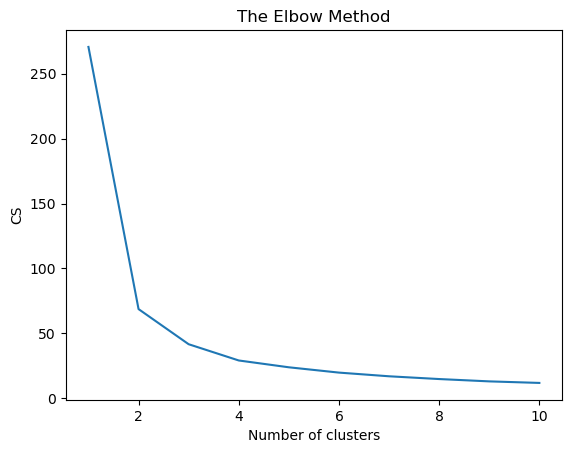

In [20]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1718 out of 2190 samples were correctly labeled.
Accuracy score: 0.78


In [22]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 196 out of 2190 samples were correctly labeled.
Accuracy score: 0.09


In [23]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [24]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [25]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [26]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [27]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,Centroid_2,cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.293300,0.018267,2.050306,0
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.354450,0.104912,2.073531,0
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0.098959,1.229590,1.048390,1
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,1.369204,0.129050,2.077559,0
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,1.111282,2.053970,0.358658,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.344092,0.094645,2.071033,0
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.344092,0.094645,2.071033,0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.344972,0.090604,2.069485,0
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.344092,0.094645,2.071033,0


In [28]:
score_dataset(X, y)

0.8782330252874742


In [29]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.206263
Centroid_2       0.196733
sunshine         0.176016
cluster          0.172312
Centroid_1       0.169356
Centroid_0       0.162969
humidity         0.144844
temparature      0.045352
dewpoint         0.029435
mintemp          0.020906
winddirection    0.011010
maxtemp          0.004499
pressure         0.003223
windspeed        0.000000
Name: MI Scores, dtype: float64

In [30]:
score_dataset(X, y)

0.8782330252874742


In [31]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

0.8751198948744433


In [32]:
X = X.drop(labels = ("winddirection"), axis=1)
X_test = X_test.drop(labels = ("winddirection"), axis=1)
score_dataset(X, y)

0.8710280995850281


In [33]:
features = ["cloud", "Centroid_2", "cluster", "Centroid_1", "Centroid_0", "humidity", "temparature"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud       -0.380164 -0.455885  0.131393  0.295649 -0.733355  0.071121   
Centroid_2  -0.441360  0.349514 -0.160214  0.028605  0.063243  0.639541   
cluster      0.440644 -0.349394  0.173779 -0.036591  0.008521 -0.080658   
Centroid_1   0.458322 -0.272116  0.148045 -0.084758 -0.006900  0.760540   
Centroid_0  -0.356780 -0.481862  0.218004  0.368408  0.673945  0.026234   
humidity    -0.296108 -0.442928 -0.305929 -0.786984  0.055942 -0.008248   
temparature  0.203663 -0.213328 -0.873975  0.384944  0.027206  0.015677   

                  PC7  
cloud        0.010210  
Centroid_2   0.493499  
cluster      0.803517  
Centroid_1  -0.329126  
Centroid_0  -0.048757  
humidity    -0.001310  
temparature  0.003383  


In [34]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,Centroid_0,Centroid_1,Centroid_2,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,1.293300,0.018267,2.050306,0,-1.844936,0.015971,0.207775,-0.205842,-0.035157,-0.077568,0.030059
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,1.354450,0.104912,2.073531,0,-2.370837,-0.448809,0.576490,-1.192992,-0.023571,0.018081,0.001141
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,0.098959,1.229590,1.048390,1,2.068516,1.949849,1.177227,-1.214482,-0.401341,-0.112919,0.005100
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,1.369204,0.129050,2.077559,0,-2.420925,-0.609220,0.465929,-1.050954,-0.158716,0.063210,-0.004800
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,1.111282,2.053970,0.358658,2,3.644842,1.078989,2.691333,1.940635,1.036544,0.068352,0.116653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,1.339299,0.086548,2.068992,0,-2.234516,-0.616865,-0.152958,-1.182288,0.108495,-0.006488,0.007688
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,1.344092,0.094645,2.071033,0,-2.135997,-0.148439,0.638045,-0.816930,0.055770,-0.000552,0.004067
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,1.121720,2.026831,0.119402,2,1.933623,-1.338623,2.281488,-0.377694,-0.167153,-0.054511,-0.012680
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,1.356964,0.109301,2.073409,0,-2.364959,-0.263891,0.995294,-0.981176,-0.131474,0.028170,-0.000447


In [35]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [36]:
#když bylo vyhozené id a day bylo to 0.8745862843729195
score_dataset(X, y)

0.8724998834042215


In [37]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,Centroid_0,Centroid_1,Centroid_2,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,1.293300,0.018267,2.050306,0,-1.844936,0.015971,0.207775,-0.205842,-0.035157,-0.077568,0.030059
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,1.354450,0.104912,2.073531,0,-2.370837,-0.448809,0.576490,-1.192992,-0.023571,0.018081,0.001141
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,0.098959,1.229590,1.048390,1,2.068516,1.949849,1.177227,-1.214482,-0.401341,-0.112919,0.005100
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,1.369204,0.129050,2.077559,0,-2.420925,-0.609220,0.465929,-1.050954,-0.158716,0.063210,-0.004800
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,1.111282,2.053970,0.358658,2,3.644842,1.078989,2.691333,1.940635,1.036544,0.068352,0.116653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,1.339299,0.086548,2.068992,0,-2.234516,-0.616865,-0.152958,-1.182288,0.108495,-0.006488,0.007688
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,1.344092,0.094645,2.071033,0,-2.135997,-0.148439,0.638045,-0.816930,0.055770,-0.000552,0.004067
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,1.121720,2.026831,0.119402,2,1.933623,-1.338623,2.281488,-0.377694,-0.167153,-0.054511,-0.012680
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,1.356964,0.109301,2.073409,0,-2.364959,-0.263891,0.995294,-0.981176,-0.131474,0.028170,-0.000447


In [38]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8937878787878788


In [42]:
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [43]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('submission_2dts_k-mean_PCA_2.csv', columns=['id','rainfall'], index=False)